# Processamento

#### 1 Importação de bibliotecas
Nesta célula, é feita a importação das principais bibliotecas e funções usadas tanto para o processamento quanto para os modelos testados.

In [2]:
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from IPython.display import display
from plotly.subplots import make_subplots
import plotly.io as pio 
pio.renderers.default = "vscode"

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import recall_score, ConfusionMatrixDisplay, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier

# Caminhos de entrada
XLSX1_PATH = "../Datos_Anonimo_20231_v2.xlsx"  # 1º semestre
XLSX2_PATH = "../Datos_Anonimo_20232_v2.xlsx"  # 2º semestre
SHEET_INDEX = 1  # segunda aba

#### 1.2 Importando todas as tabelas/dados

Nesta célula, será colocada em variáveis (df1, df2, ...) com o objetivo de ser possível usá-las nos treinamentos e nos testes dos modelos.

In [3]:
df1 = pd.read_csv('dados/dados_modelo1.csv')
df2 = pd.read_csv('dados/dados_modelo2.csv')
df3 = pd.read_csv('dados/dados_modelo3.csv')
df1_test = pd.read_csv('dados/dados_teste1.csv')
df2_test = pd.read_csv('dados/dados_teste2.csv')
df3_test = pd.read_csv('dados/dados_teste3.csv')

#### 1.3 Separação da variável alvo nos 3 treinos e testes

Nesta célula será feita a definição de qual variável irá ser prevista (exemplo: X1_train = df1.drop('Reprovou', axis = 1)) e qual feature não entrará no treinamento e no teste dos modelos escolhidos.

In [ ]:
X1_train = df1.drop('Reprovou', axis = 1)
y1_train = df1['Reprovou']

X2_train = df2.drop('Reprovou', axis = 1)
y2_train = df2['Reprovou']

X3_train = df3.drop('Reprovou', axis = 1)
y3_train = df3['Reprovou']

X1_test = df1_test.drop('Reprovou', axis = 1)
y1_test = df1_test['Reprovou']

X2_test = df2_test.drop('Reprovou', axis = 1)
y2_test = df2_test['Reprovou']

X3_test = df3_test.drop('Reprovou', axis = 1)
y3_test = df3_test['Reprovou']

#### 1.4 Trocando Valores 

Na coluna "TempoQ3", existe um dado que está Nulo, então aqui será feita a substituição paar 

In [5]:
X1_train['TempoQ3'] = X1_train['TempoQ3'].fillna(0)
X2_train['TempoQ3'] = X2_train['TempoQ3'].fillna(0)
X3_train['TempoQ3'] = X3_train['TempoQ3'].fillna(0)

# XGBoost

In [6]:
def xgb_classifier(x_train, x_test, y_train, y_test):

    # Aplicando SMOTE apenas no treino
    sm = SMOTE(random_state=42)
    x_train, y_train = sm.fit_resample(x_train, y_train)

    # Definição do classificador com parâmetros default
    xgb = XGBClassifier(random_state=42, eval_metric='logloss')

    # Adição do GridSearchCV
    param_grid_xgb = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1]
    }

    # Aplicação do GridSearch
    grid = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='recall')
    grid.fit(x_train, y_train)

    # Imprimindo os melhores parâmetros encontrados
    print("Melhores parâmetros encontrados:", grid.best_params_)
    
    # Previsões no conjunto de teste usando o MELHOR modelo encontrado pelo grid
    y_pred = grid.predict(x_test)

    # Apresentação das métricas obtidas:
    print("\n--- Métricas obtidas ---")

    # Obtenção do Recall
    recall = recall_score(y_test, y_pred, pos_label=1)
    print("Recall da classe 0 no teste: ", recall)
    # Obtenção do F1 Score
    f1score = f1_score(y_test, y_pred, pos_label=1)
    print("F1 Score da classe 1 no teste: ", f1score)

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred, labels=[1,0])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Reprovado (1)", "Aprovado (0)"]
    )
    disp.plot(cmap="Blues", values_format="d")

    plt.title("Matriz de Confusão - XGBClassifier")
    plt.show()


Melhores parâmetros encontrados: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}

--- Métricas obtidas ---
Recall da classe 0 no teste:  0.7692307692307693
F1 Score da classe 1 no teste:  0.39603960396039606


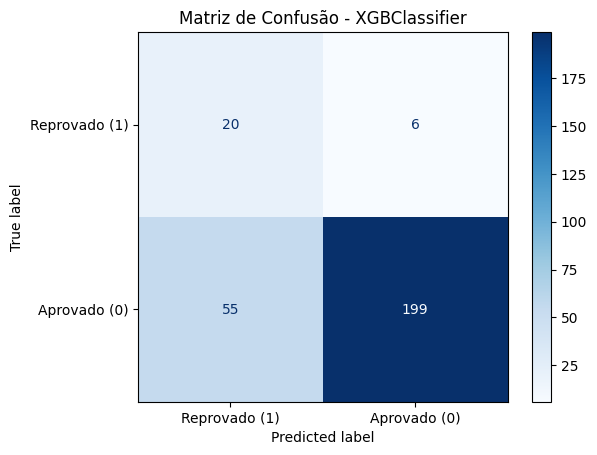

In [7]:
xgb_classifier(X1_train, X1_test, y1_train, y1_test)

Melhores parâmetros encontrados: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}

--- Métricas obtidas ---
Recall da classe 0 no teste:  0.5384615384615384
F1 Score da classe 1 no teste:  0.5384615384615384


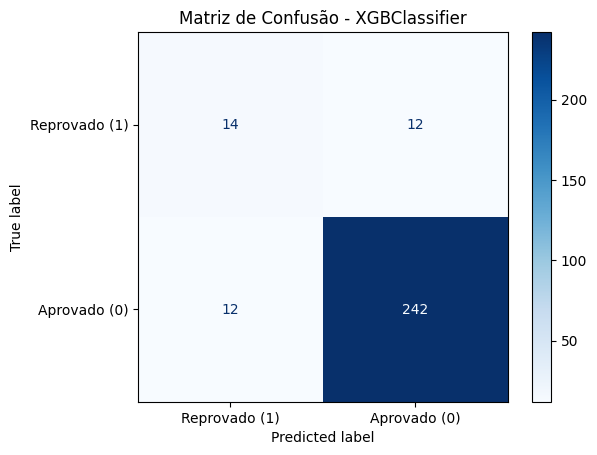

In [8]:
xgb_classifier(X2_train, X2_test, y2_train, y2_test)

Melhores parâmetros encontrados: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

--- Métricas obtidas ---
Recall da classe 0 no teste:  0.5384615384615384
F1 Score da classe 1 no teste:  0.5957446808510638


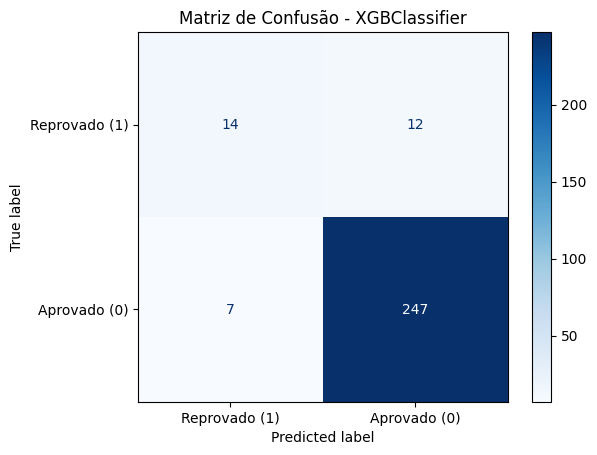

In [9]:
xgb_classifier(X3_train, X3_test, y3_train, y3_test)

# AdaBoost

In [10]:
def adaboost(x_train, x_test, y_train, y_test):
    # Se ainda não dividiu os dados
    # x_train, x_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

    # Aplicando SMOTE apenas no treino
    sm = SMOTE(random_state=42)
    x_train, y_train = sm.fit_resample(x_train, y_train)

    # Definição do classificador (parâmetros default)
    ab = AdaBoostClassifier(random_state=42)  # n_estimators=50, learning_rate=1.0

    # Parametros do GridSearchCV
    param_grid_ada = {
        'n_estimators': [50, 100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.5, 1.0]
    }

    # Aplicação do Grid SearchCv
    grid = GridSearchCV(ab, param_grid_ada, cv=5, scoring='recall', n_jobs=-1)
    grid.fit(x_train, y_train)

    # Imprimindo os melhores parâmetros que a busca encontrou
    print("Melhores parâmetros encontrados:", grid.best_params_)

    # Previsões no conjunto de teste usando o melhor modelo
    y_pred = grid.predict(x_test)   

    # Obtenção do Recall
    recall = recall_score(y_test, y_pred, pos_label=1)
    print("Recall da classe 1 no teste: ", recall)
    # Obtenção do F1 Score
    f1score = f1_score(y_test, y_pred, pos_label=1)
    print("F1 Score da classe 1 no teste: ", f1score)

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred, labels=[1,0])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Reprovado (1)", "Aprovado (0)"]
    )
    disp.plot(cmap="Blues", values_format="d")

    plt.title("Matriz de Confusão - AdaBoost")
    plt.show()

Melhores parâmetros encontrados: {'learning_rate': 0.1, 'n_estimators': 50}
Recall da classe 1 no teste:  0.8076923076923077
F1 Score da classe 1 no teste:  0.3387096774193548


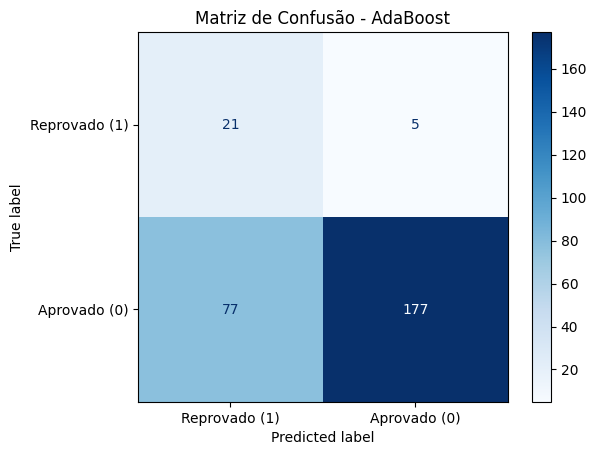

In [11]:
adaboost(X1_train, X1_test, y1_train, y1_test)

Melhores parâmetros encontrados: {'learning_rate': 1.0, 'n_estimators': 300}
Recall da classe 1 no teste:  0.6923076923076923
F1 Score da classe 1 no teste:  0.37894736842105264


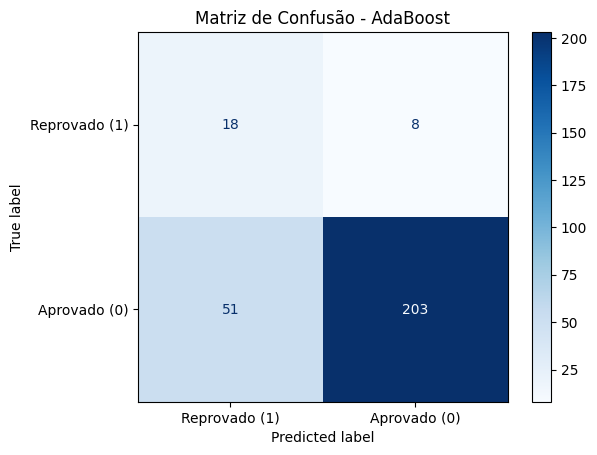

In [12]:
adaboost(X2_train, X2_test, y2_train, y2_test)

Melhores parâmetros encontrados: {'learning_rate': 0.01, 'n_estimators': 300}
Recall da classe 1 no teste:  0.6923076923076923
F1 Score da classe 1 no teste:  0.4931506849315068


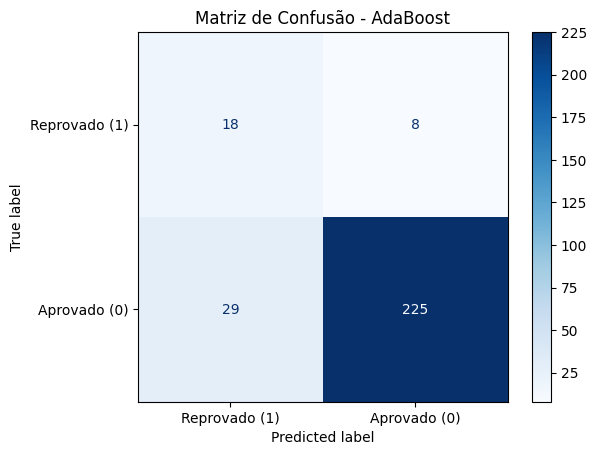

In [13]:
adaboost(X3_train, X3_test, y3_train, y3_test)